In [ ]:
import pandas as pd
import cnsplots as cns
import matplotlib.pyplot as plt
from pathlib import Path
import seaborn as sns
import tol_colors as tc

In [2]:
#######################
# Panel A: Precision, Recall, F1 for subcategory prediction using various pLM embeddings
#######################
input_dir = Path("./input_data/pLM_PhageOnly_metrics")

dfs = []

for file in input_dir.glob("*.csv"):
    df = pd.read_csv(file)
    df["LM"] = file.stem
    dfs.append(df)

df_all = pd.concat(dfs, ignore_index=True)

df_all.rename(columns={"bv_test_indiv_f1": "F1", "bv_test_indiv_recall": "Recall", "bv_test_indiv_precision": "Precision"}, inplace=True)
metrics_long = df_all.melt(id_vars="LM", value_vars=["F1", "Recall", "Precision"], var_name="Metric", value_name="Score")

/ceph/ibmi/it/thesis_data/scheuren/miniforge3/envs/cnsplots/lib/python3.14/site-packages/cnsplots/_svg.py:101: RuntimeWarning: MuPDF's `mutool` is unavailable; saved a standard matplotlib SVG instead.
  _save_plain_svg(


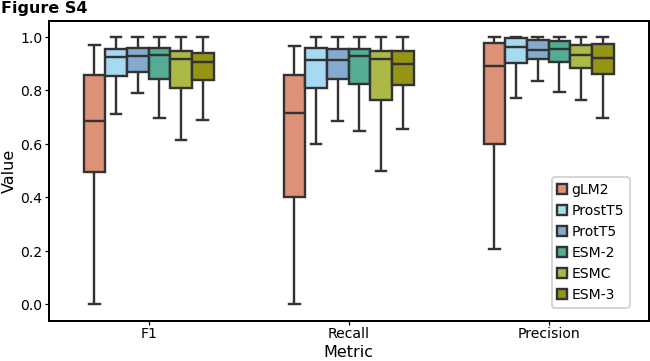

In [17]:
cns.settings.title_fontweight = "normal"
mp = cns.multipanel(
    max_width=400, title="Figure S4", title_fontweight="bold", loc="left"
)

######################
# Panel A: Precision, Recall, F1 of MLP, CNN, CNN+MLP for subcategory prediction
mp.panel("", 300, 150)
ax = plt.gca()

#palette_lms = {"gLM2": tc.muted.cyan, "ProstT5": tc.muted.teal, "ProtT5": tc.muted.green, "ESM-2": tc.muted.wine, "ESMC": tc.muted.purple, "ESM-3": tc.muted.rose}

palette_lms = {"gLM2": tc.light.orange, "ProstT5": tc.light.light_cyan, "ProtT5": tc.light.light_blue, "ESM-2": tc.light.mint, "ESMC": tc.light.pear, "ESM-3": tc.light.olive}

metric_order = ["F1", "Recall", "Precision"]
lm_order = list(palette_lms.keys())

sns.boxplot(data=metrics_long, x="Metric", y="Score", hue="LM", order=metric_order, hue_order=lm_order, dodge=True, palette=palette_lms, width=0.65, linewidth=1.2, fliersize=0, ax=ax)

#sns.stripplot(data=metrics_long, x="Metric", y="Score", hue="LM", order=metric_order, hue_order=lm_order, dodge=True, jitter=True, color="black", alpha=0.3, size=1, ax=ax)

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[:6], labels[:6], title=None, frameon=True, loc="lower right", bbox_to_anchor=(0.98, 0.02))

ax.set_xlabel("Metric")
#ax.set_xticklabels([])
ax.set_ylabel("Value")
ax.set_ylim(-0.06, 1.06)

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color("black")
    spine.set_linewidth(1) 

# Save final figure
outdir = Path("./plots/")
outdir.mkdir(parents=True, exist_ok=True)
cns.savefig(outdir / "FigureS4.svg")